# VectorFFT vs FFTW vs Intel MKL

Split-complex batched 1D FFT (double precision, single-threaded AVX2, i9-14900KF)

Results from scalar-twiddle optimized build (April 2026)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'sans-serif'

In [ ]:
# Benchmark data from latest run (scalar-twiddle optimized, April 2026)
# (N, K, factors, ours_ns, fftw_ns, mkl_ns)
bench_data = [
    (256,    32,   '4x8x8',           6843.4,     16864.8,     12134.4),
    (256,    256,  '8x4x8',          67735.0,    166210.0,     99500.0),
    (256,    1024, '4x4x4x4',       349640.0,    715045.0,    554830.0),
    (1024,   32,   '4x4x16x4',       33533.3,     93733.3,     59463.3),
    (1024,   256,  '4x4x4x2x8',     441395.0,    813590.0,    662075.0),
    (1024,   1024, '4x4x4x4x4',    1858375.0,   3274450.0,   3198200.0),
    (4096,   32,   '4x4x4x2x32',    223720.0,    544635.0,    339065.0),
    (4096,   256,  '4x4x2x4x32',   2511665.0,   5167325.0,   3459780.0),
    (4096,   1024, '16x4x64',      14453270.0,  38831870.0,  25273815.0),
    (16384,  32,   '4x4x4x2x4x32',  1287065.0,   5278070.0,   1792460.0),
    (16384,  256,  '4x2x4x16x32',  14980645.0,  79834615.0,  20519405.0),
    (16384,  1024, '32x4x4x32',    65090065.0, 455844095.0, 118218720.0),
    (60,     32,   '12x5',              689.4,      3314.2,      3696.3),
    (60,     256,  '12x5',             7855.4,     35395.4,     33327.7),
    (60,     1024, '5x4x3',          39245.0,    116625.0,    147425.0),
    (200,    32,   '8x5x5',           3711.5,     13160.3,     13687.8),
    (200,    256,  '4x10x5',         33505.0,    126710.0,    112530.0),
    (200,    1024, '4x5x2x5',       234075.0,    550225.0,    552310.0),
    (1000,   32,   '10x10x10',       27296.8,     88316.1,     79967.7),
    (1000,   256,  '8x5x5x5',       291030.0,    921445.0,    809410.0),
    (1000,   1024, '5x5x2x5x4',    1655255.0,   3809145.0,   3711105.0),
    (5000,   32,   '10x10x5x10',    202330.0,   1189745.0,    597295.0),
    (5000,   256,  '8x5x5x5x5',   1961975.0,  10260420.0,   5443625.0),
    (5000,   1024, '10x5x5x5x4',  14136815.0,  77407970.0,  36583265.0),
    (10000,  32,   '16x25x25',      527760.0,   3245365.0,   1417685.0),
    (10000,  256,  '5x5x16x25',    8025975.0,  63534445.0,  14646290.0),
    (10000,  1024, '16x5x5x25',   39874815.0, 385435280.0,  87445675.0),
    (20000,  32,   '16x2x25x25',   1190920.0,   8112945.0,   3928440.0),
    (20000,  256,  '5x5x32x25',   17162935.0, 161174175.0,  37799760.0),
    (50000,  32,   '20x20x25x5',   3273840.0,  38802115.0,  10223970.0),
    (50000,  256,  '5x16x5x5x25', 49989260.0, 800863580.0,  88616580.0),
    (49,     32,   '7x7',              733.0,      3374.1,      3009.9),
    (49,     256,  '7x7',              6363.3,    28025.3,     28730.4),
    (143,    32,   '13x11',            3775.7,    11606.9,     11933.9),
    (143,    256,  '11x13',           28255.6,   108040.7,     99733.3),
    (875,    32,   '25x5x7',          24100.0,    85931.4,     79265.7),
    (875,    256,  '5x5x5x7',       256710.0,  1100275.0,    782030.0),
    (2401,   32,   '7x7x7x7',        84790.0,   302340.0,    250490.0),
    (2401,   256,  '7x7x7x7',       808675.0,  4587430.0,   2610025.0),
    (8000,   256,  '4x5x5x2x8x5',  4452230.0,  20373910.0,  9250090.0),
    (12000,  256,  '32x5x5x5x3',   7894510.0,  72867540.0, 16854235.0),
    (25000,  256,  '8x5x5x5x25',  18866420.0, 172031500.0, 41587445.0),
    (40000,  256,  '5x5x64x25',   39552780.0, 651841820.0, 76849285.0),
    (100000, 32,   '32x25x25x5',   8743845.0, 122267735.0, 22297060.0),
]

N_arr    = np.array([d[0] for d in bench_data], dtype=float)
K_arr    = np.array([d[1] for d in bench_data], dtype=float)
ours_ns  = np.array([d[3] for d in bench_data])
fftw_ns  = np.array([d[4] for d in bench_data])
mkl_ns   = np.array([d[5] for d in bench_data])
has_mkl  = True

def is_pow2(n):
    n = int(n)
    return n > 0 and (n & (n-1)) == 0

print(f'{len(N_arr)} test cases loaded, MKL: {has_mkl}')

C:\Users\Tugbars\AppData\Local\Temp\ipykernel_31884\983926520.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=8, ncol=3, framealpha=0.9)


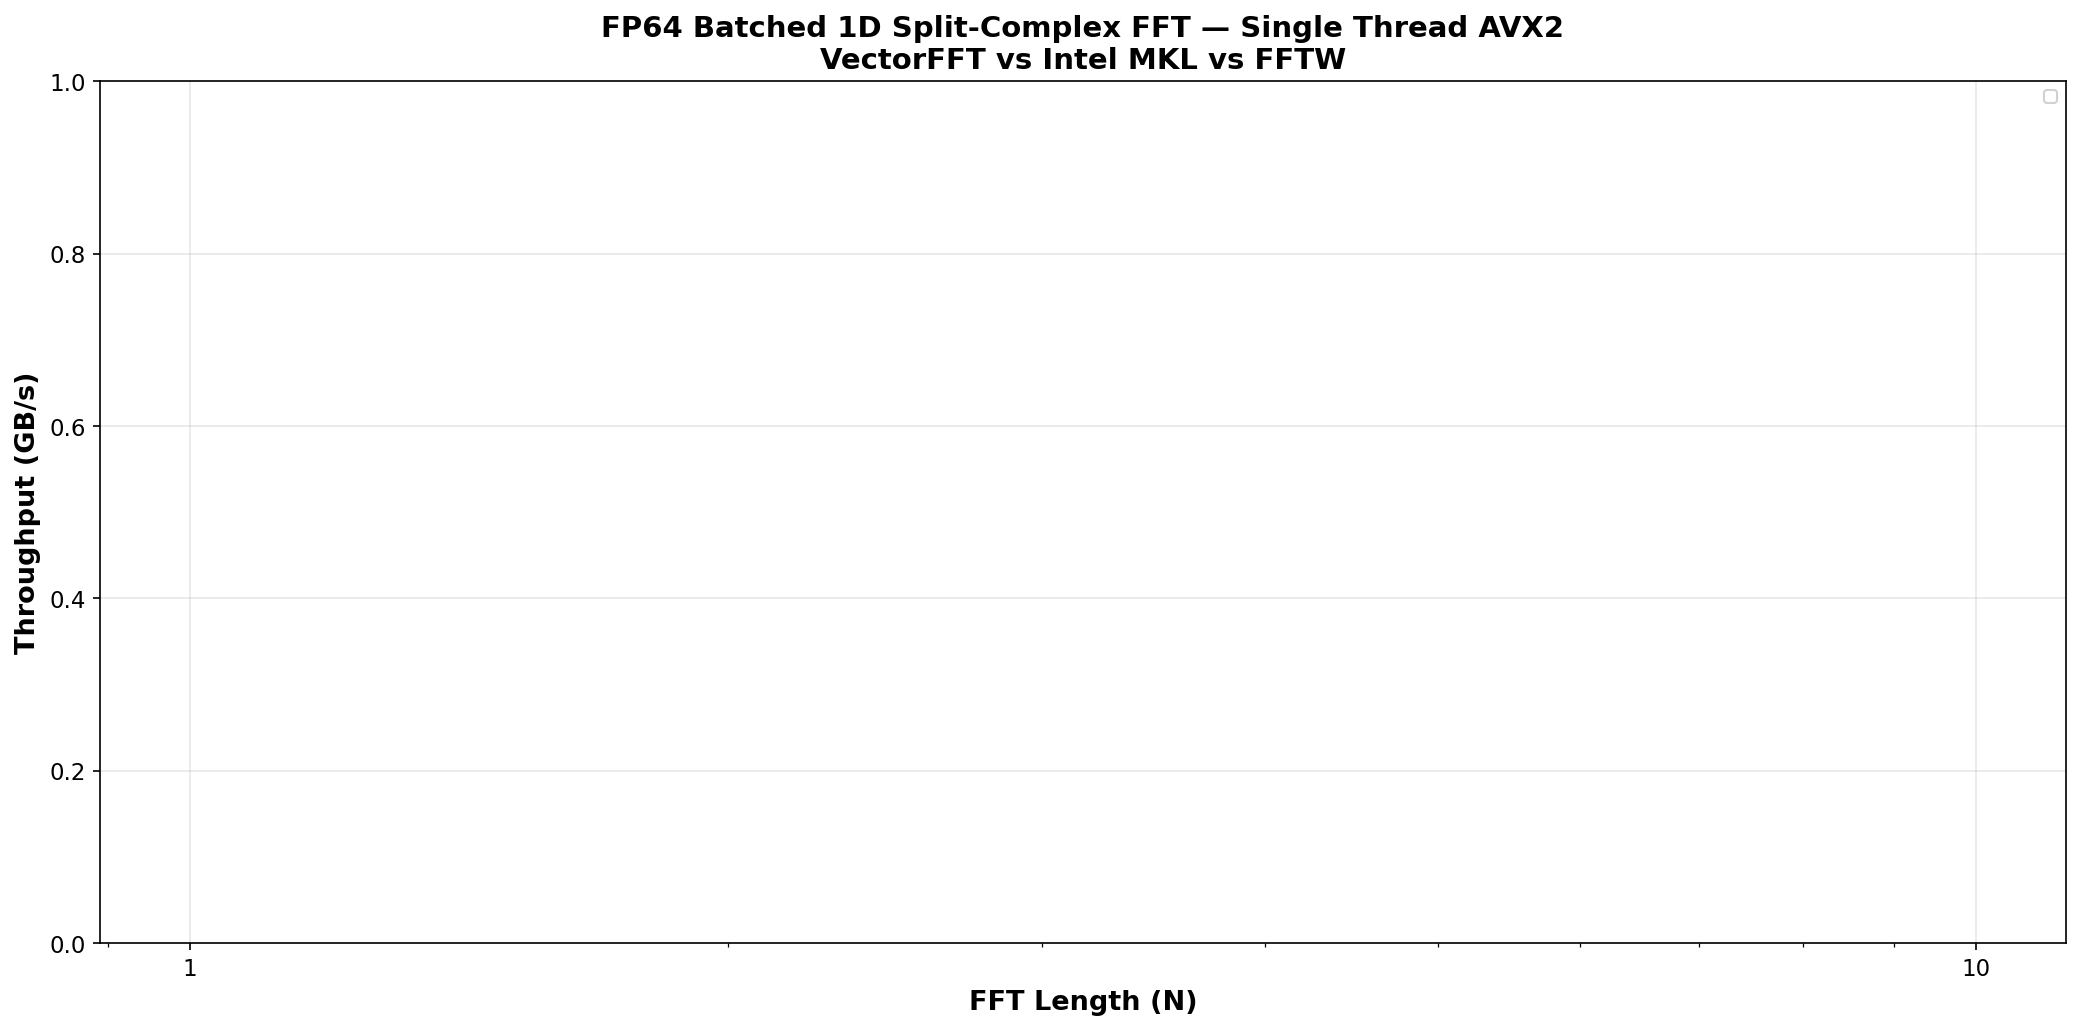

In [3]:
# ── Plot 1: Throughput (GB/s) scatter ──
data_bytes = 2.0 * N_arr * K_arr * 8
ours_gbs = data_bytes / ours_ns
fftw_gbs = data_bytes / fftw_ns
mkl_gbs = data_bytes / mkl_ns

fig, ax = plt.subplots(figsize=(14, 7))

used_labels = set()
for lib, gbs, marker, colors, label_base in [
    ('ours', ours_gbs, 'o', ['#e41a1c','#ff6b6b','#ffaaaa'], 'VectorFFT'),
    ('mkl',  mkl_gbs,  's', ['#377eb8','#74b3e8','#b3d4f0'], 'Intel MKL'),
    ('fftw', fftw_gbs, '^', ['#4daf4a','#8dd38b','#c4e8c3'], 'FFTW'),
]:
    for ki, Kv in enumerate([32, 256, 1024]):
        m = K_arr == Kv
        if not np.any(m): continue
        lbl = f'{label_base} K={Kv}'
        ax.scatter(N_arr[m], gbs[m], marker=marker, s=60, alpha=0.85,
                   color=colors[ki], edgecolors='black', linewidth=0.3,
                   label=lbl if lbl not in used_labels else None,
                   zorder=5 if lib=='ours' else 3)
        used_labels.add(lbl)

ax.set_xlabel('FFT Length (N)', fontsize=13, fontweight='bold')
ax.set_ylabel('Throughput (GB/s)', fontsize=13, fontweight='bold')
ax.set_title('FP64 Batched 1D Split-Complex FFT — Single Thread AVX2\n'
             'VectorFFT vs Intel MKL vs FFTW', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=8, ncol=3, framealpha=0.9)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('vfft_throughput.png', dpi=200, bbox_inches='tight')
plt.show()

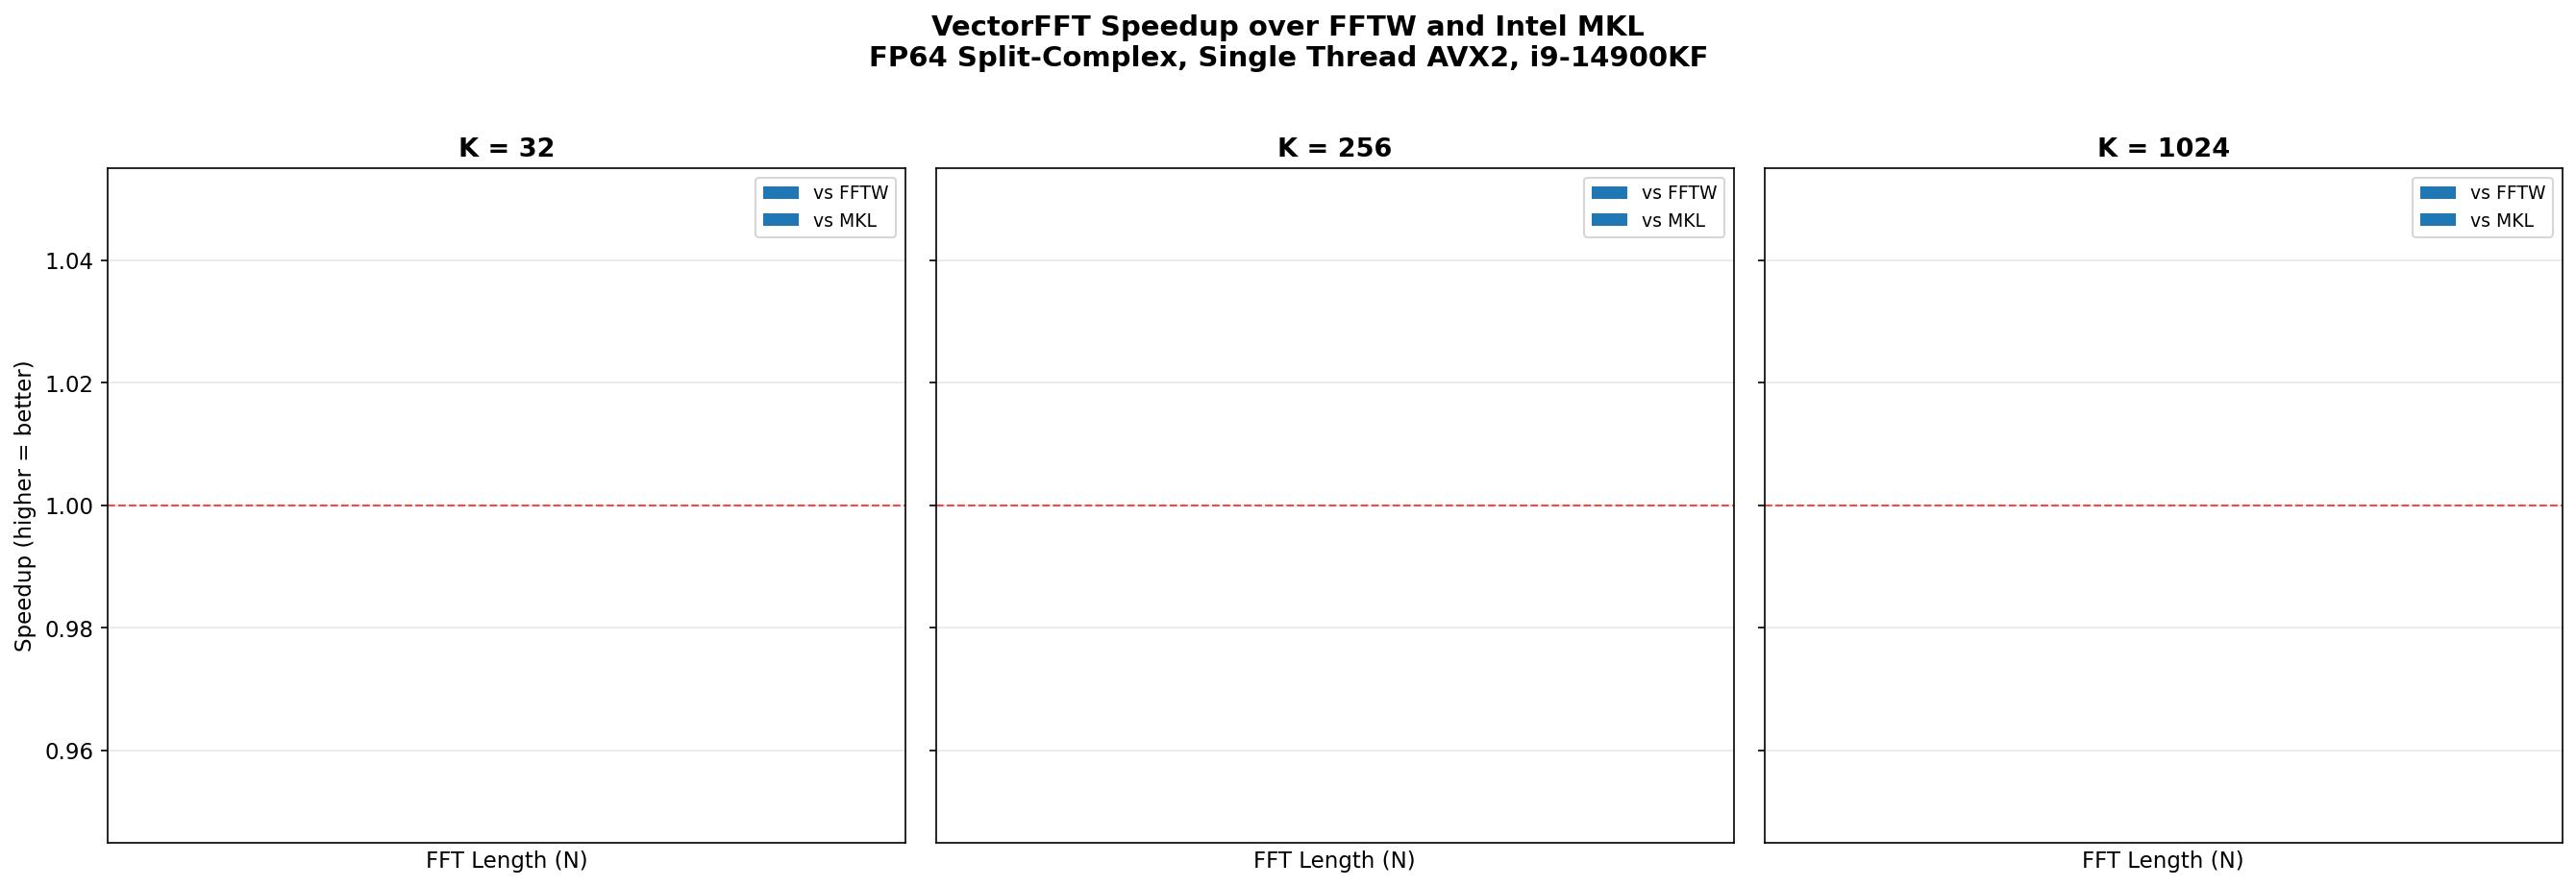

In [4]:
# ── Plot 2: Speedup bars per K ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for ki, Kv in enumerate([32, 256, 1024]):
    ax = axes[ki]
    m = K_arr == Kv
    Ns = N_arr[m]; vs_fw = fftw_ns[m]/ours_ns[m]; vs_mk = mkl_ns[m]/ours_ns[m]
    o = np.argsort(Ns); Ns=Ns[o]; vs_fw=vs_fw[o]; vs_mk=vs_mk[o]
    x = np.arange(len(Ns)); w = 0.35
    ax.bar(x-w/2, vs_fw, w, label='vs FFTW', color='#4daf4a', alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.bar(x+w/2, vs_mk, w, label='vs MKL',  color='#377eb8', alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{int(n):,}' for n in Ns], rotation=45, ha='right', fontsize=8)
    ax.set_title(f'K = {Kv}', fontsize=13, fontweight='bold')
    ax.set_xlabel('FFT Length (N)')
    if ki==0: ax.set_ylabel('Speedup (higher = better)')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

fig.suptitle('VectorFFT Speedup over FFTW and Intel MKL\n'
             'FP64 Split-Complex, Single Thread AVX2, i9-14900KF',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('vfft_speedup_bars.png', dpi=200, bbox_inches='tight')
plt.show()

ValueError: zero-size array to reduction operation fmax which has no identity

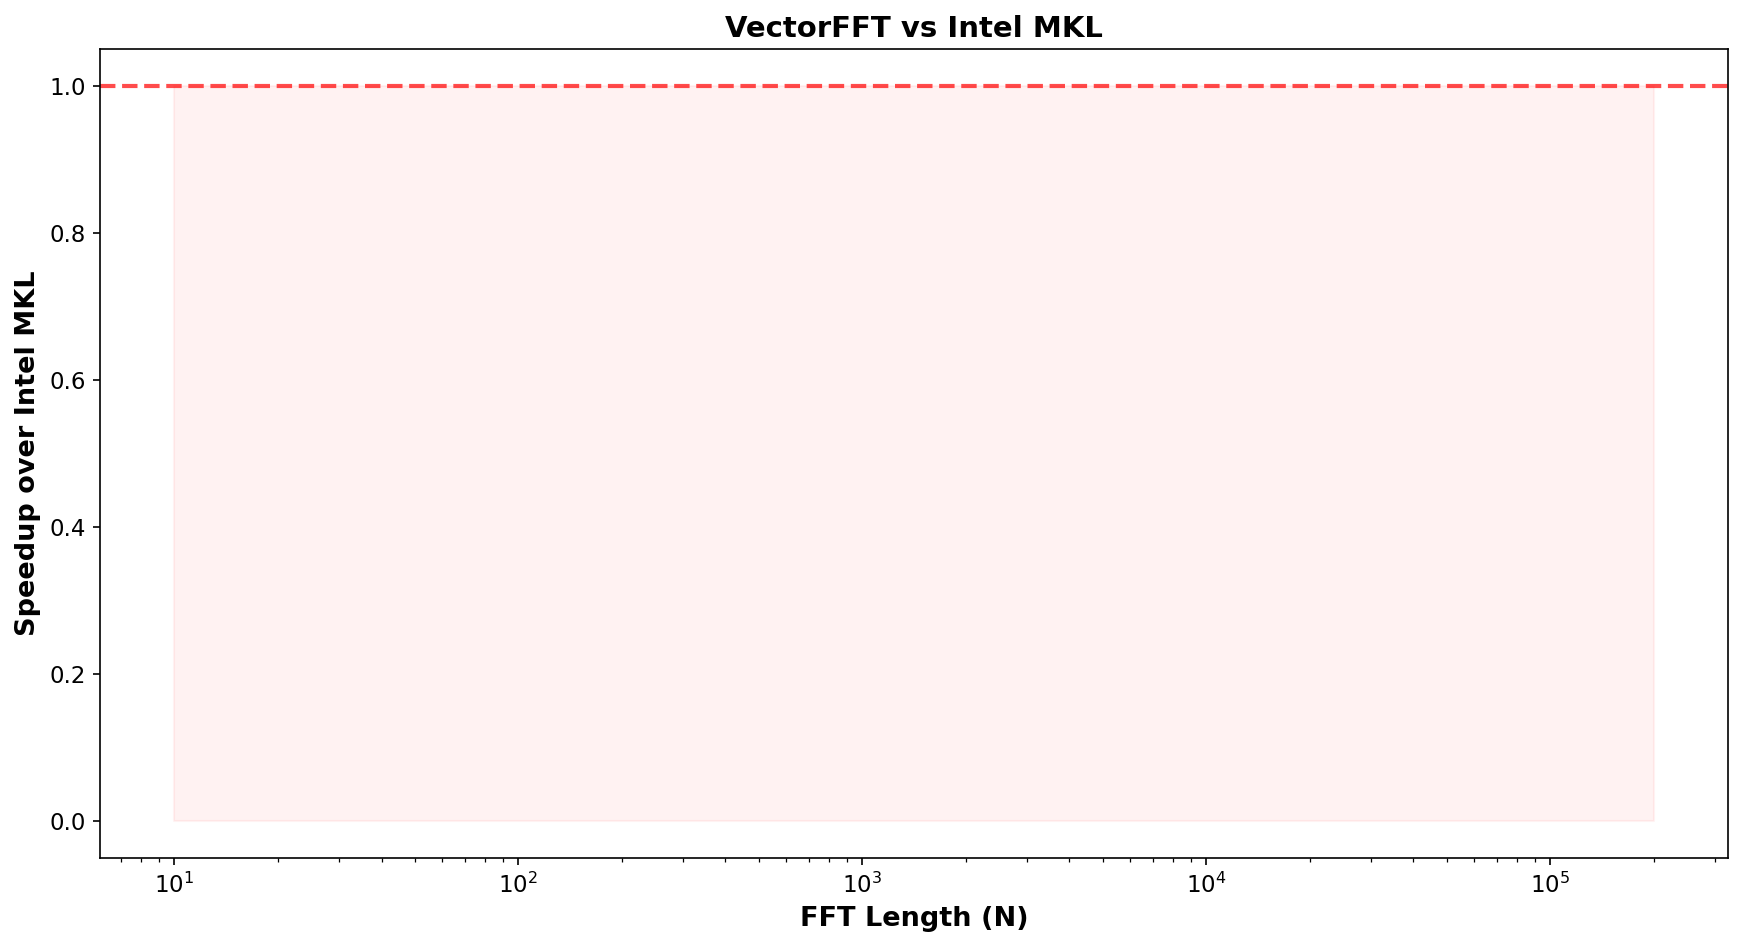

In [5]:
# ── Plot 3: vs MKL scatter ──
vs_mkl_all = mkl_ns / ours_ns
fig, ax = plt.subplots(figsize=(14, 7))
pow2_mask = np.array([is_pow2(n) for n in N_arr], dtype=bool)

used_labels = set()
for Kv, marker, sz in [(32,'o',80),(256,'s',80),(1024,'D',80)]:
    m = (K_arr == Kv)
    m2 = m & pow2_mask
    if np.any(m2):
        lbl = f'pow2 K={Kv}'
        ax.scatter(N_arr[m2], vs_mkl_all[m2], marker=marker, s=sz, color='#e41a1c',
                   edgecolors='black', linewidth=0.5, alpha=0.9,
                   label=lbl if lbl not in used_labels else None, zorder=5)
        used_labels.add(lbl)
    mc = m & ~pow2_mask
    if np.any(mc):
        lbl = f'composite K={Kv}'
        ax.scatter(N_arr[mc], vs_mkl_all[mc], marker=marker, s=sz, color='#377eb8',
                   edgecolors='black', linewidth=0.5, alpha=0.9,
                   label=lbl if lbl not in used_labels else None, zorder=5)
        used_labels.add(lbl)

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.fill_between([10,200000], 0, 1, color='red', alpha=0.05)
ax.set_xlabel('FFT Length (N)', fontsize=13, fontweight='bold')
ax.set_ylabel('Speedup over Intel MKL', fontsize=13, fontweight='bold')
ax.set_title('VectorFFT vs Intel MKL', fontsize=14, fontweight='bold')
ax.set_xscale('log'); ax.set_ylim(0, float(np.nanmax(vs_mkl_all))*1.1)
ax.grid(True, alpha=0.3)
if used_labels:
    ax.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.9)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('vfft_vs_mkl.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# ── Summary statistics ──
vs_mkl_all = mkl_ns / ours_ns
vs_fftw_all = fftw_ns / ours_ns
pow2_mask = np.array([is_pow2(n) for n in N_arr], dtype=bool)
comp_mask = ~pow2_mask

print('=== VectorFFT Benchmark Summary ===')
print(f'\nvs FFTW_MEASURE:  {vs_fftw_all.min():.2f}x - {vs_fftw_all.max():.2f}x  (mean {vs_fftw_all.mean():.2f}x, median {np.median(vs_fftw_all):.2f}x)')
print(f'vs Intel MKL:     {vs_mkl_all.min():.2f}x - {vs_mkl_all.max():.2f}x  (mean {vs_mkl_all.mean():.2f}x, median {np.median(vs_mkl_all):.2f}x)')
print(f'  Wins vs MKL:    {np.sum(vs_mkl_all > 1.0)}/{len(vs_mkl_all)}')

if np.any(comp_mask):
    print(f'\nComposite N:  mean {vs_mkl_all[comp_mask].mean():.2f}x  median {np.median(vs_mkl_all[comp_mask]):.2f}x vs MKL')
if np.any(pow2_mask):
    print(f'Power-of-2 N: mean {vs_mkl_all[pow2_mask].mean():.2f}x  median {np.median(vs_mkl_all[pow2_mask]):.2f}x vs MKL')
print(f'\n{len(N_arr)} test cases total')

---
## Prime-N Results (Rader + Bluestein)

Smooth primes (N-1 is 19-smooth) use **Rader's** algorithm.  
Non-smooth primes use **Bluestein's** algorithm.

In [ ]:
# Prime-N benchmark data from bench_primes.c
# (N, K, method, ours_ns, fftw_ns, mkl_ns)
prime_data = [
    (29,   32,  'Rader',      1554.0,    4177.1,    4040.4),
    (29,   256, 'Rader',     15413.4,   31888.8,   34436.6),
    (61,   32,  'Rader',      3947.5,   15347.5,   21360.2),
    (61,   256, 'Rader',     52935.9,  136439.1,  176145.3),
    (97,   32,  'Rader',      6554.3,   21009.9,   21537.0),
    (97,   256, 'Rader',     70412.5,  158405.0,  180640.0),
    (127,  32,  'Rader',     10663.0,   25496.3,   19887.8),
    (127,  256, 'Rader',    101743.3,  213443.3,  170630.0),
    (181,  32,  'Rader',     15969.8,   55572.1,   44326.7),
    (181,  256, 'Rader',    185585.7,  422781.0,  353771.4),
    (251,  32,  'Rader',     21208.1,   50468.5,   43514.5),
    (251,  256, 'Rader',    252870.0,  397600.0,  356855.0),
    (337,  32,  'Rader',     30583.7,  101342.4,   98204.3),
    (337,  256, 'Rader',    314470.0,  744420.0,  810210.0),
    (401,  32,  'Rader',     36284.4,  113502.6,   90350.6),
    (401,  256, 'Rader',    386085.0,  839830.0,  723670.0),
    (449,  32,  'Rader',     44153.6,  114984.1,   87981.2),
    (449,  256, 'Rader',    466395.0,  916740.0,  783030.0),
    (53,   32,  'Rader',      3601.2,   10792.5,   15778.6),
    (53,   256, 'Rader',     41164.4,  101637.0,  127817.8),
    (131,  32,  'Rader',     10869.7,   29173.5,   31450.8),
    (131,  256, 'Rader',    111206.9,  261958.6,  270310.3),
    (263,  32,  'Bluestein',  65076.3,   67723.7,   71399.2),
    (263,  256, 'Bluestein', 589105.0,  518260.0,  592320.0),
    (509,  32,  'Bluestein', 123093.4,  106660.7,   96406.6),
    (509,  256, 'Bluestein',1204805.0,  860055.0,  824385.0),
    (1021, 32,  'Rader',    142653.3,  250993.3,  198966.7),
    (1021, 256, 'Rader',   1268530.0, 2134140.0, 1926505.0),
    (2053, 32,  'Rader',    333055.0,  678235.0,  729975.0),
    (2053, 256, 'Rader',   2901360.0, 7316630.0, 6512640.0),
]

p_N    = np.array([d[0] for d in prime_data])
p_K    = np.array([d[1] for d in prime_data])
p_meth = np.array([d[2] for d in prime_data])
p_ours = np.array([d[3] for d in prime_data])
p_fftw = np.array([d[4] for d in prime_data])
p_mkl  = np.array([d[5] for d in prime_data])
p_vs_fftw = p_fftw / p_ours
p_vs_mkl  = p_mkl / p_ours

rader = p_meth == 'Rader'
blue  = p_meth == 'Bluestein'

print('=== Prime-N Summary ===')
print(f'Rader ({np.sum(rader)} cases):     vs MKL {p_vs_mkl[rader].min():.2f}x - {p_vs_mkl[rader].max():.2f}x  (mean {p_vs_mkl[rader].mean():.2f}x)')
print(f'Bluestein ({np.sum(blue)} cases): vs MKL {p_vs_mkl[blue].min():.2f}x - {p_vs_mkl[blue].max():.2f}x  (mean {p_vs_mkl[blue].mean():.2f}x)')

=== Prime-N Summary ===
Rader (26 cases):     vs MKL 1.39x - 5.41x  (mean 2.50x)
Bluestein (4 cases): vs MKL 0.68x - 1.10x  (mean 0.89x)


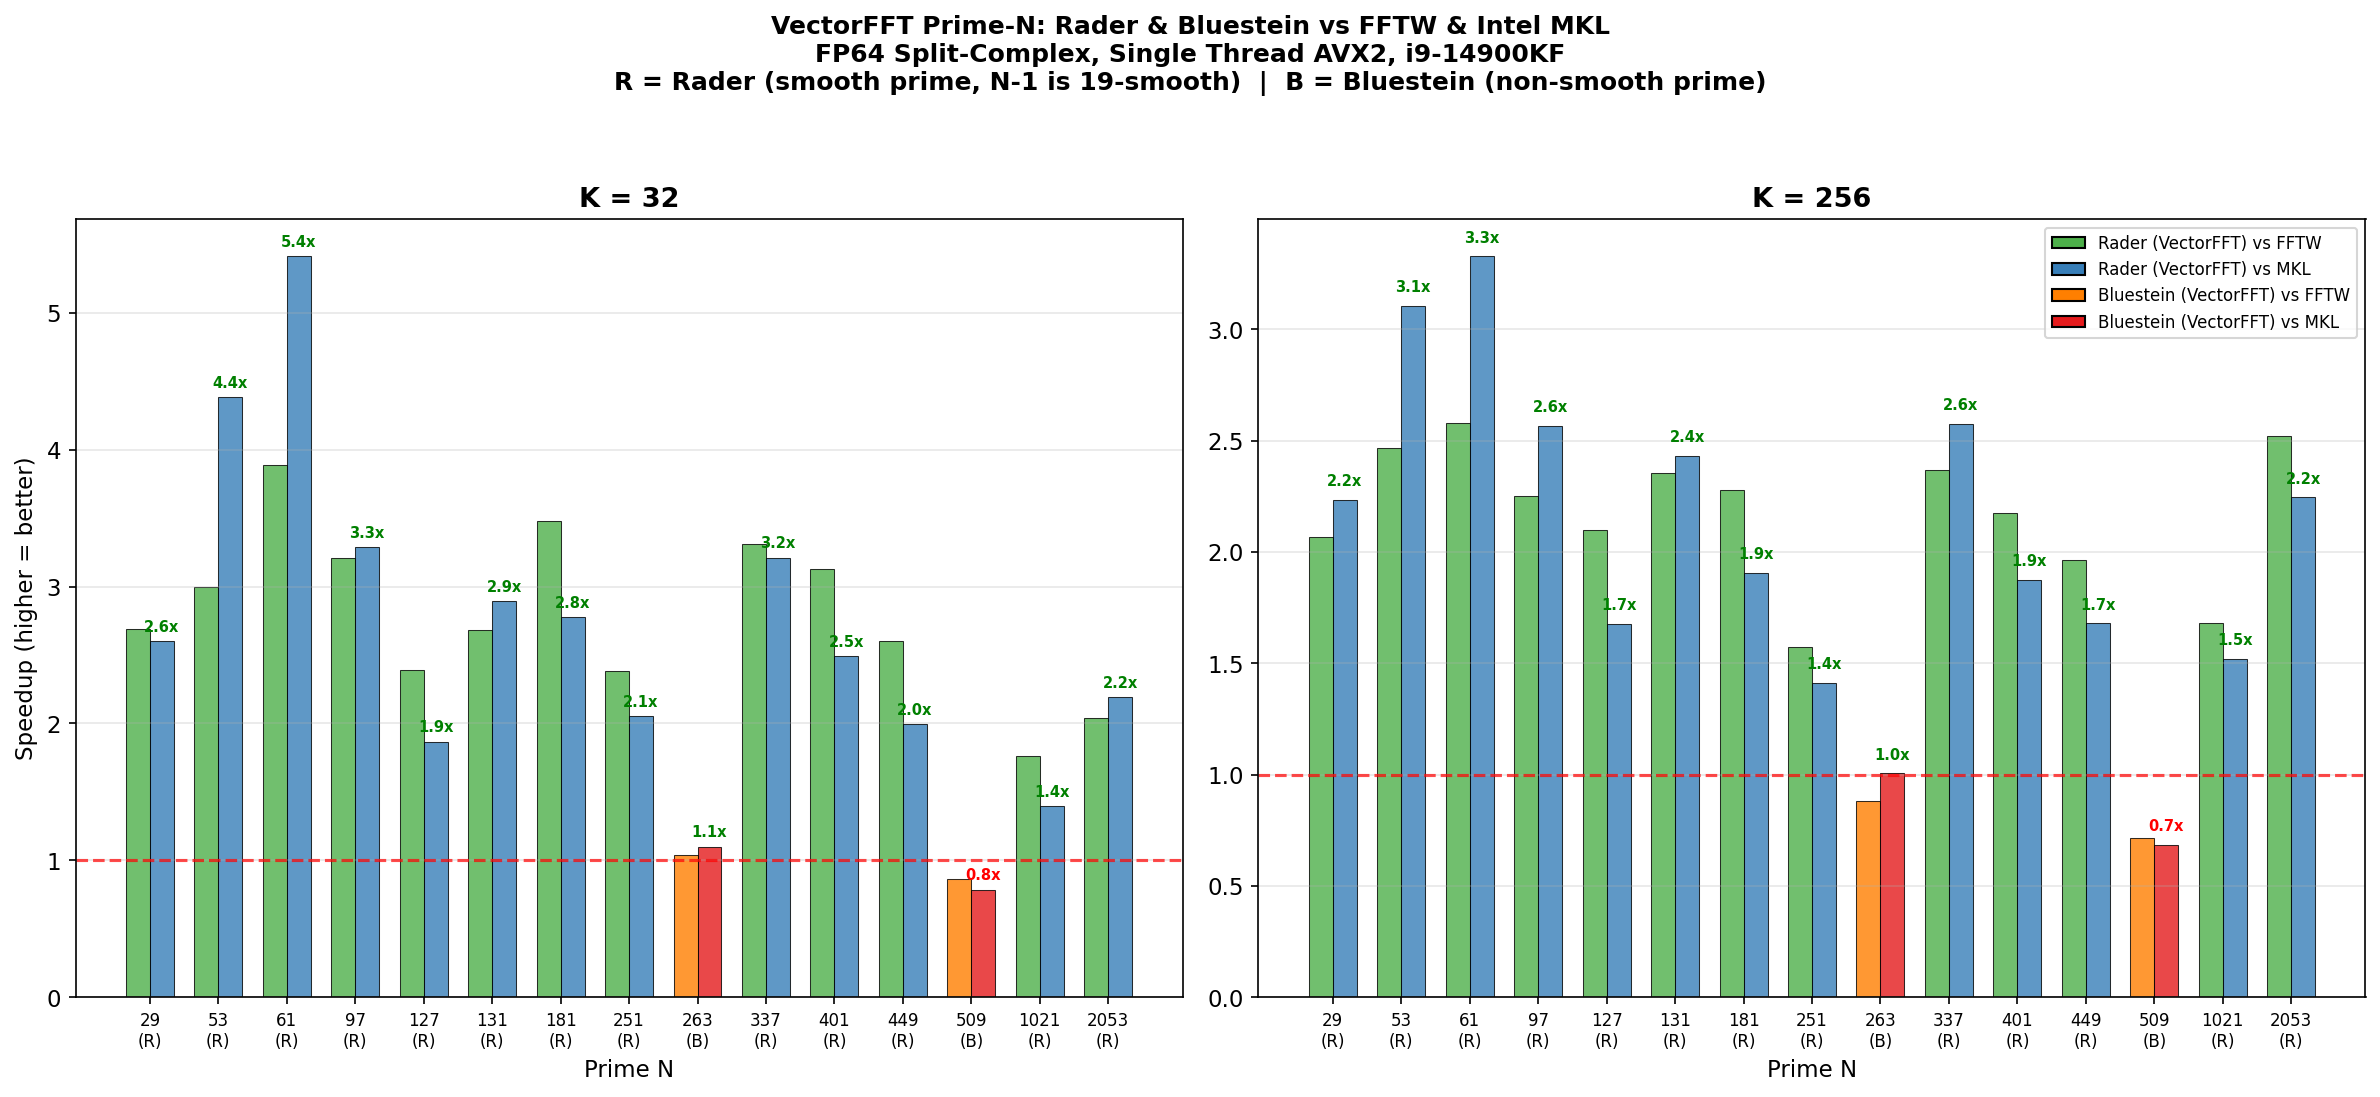

Saved: vfft_primes.png


In [ ]:
# ── Plot 5: Prime-N speedup bars ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, Kv, title in [(ax1, 32, 'K = 32'), (ax2, 256, 'K = 256')]:
    m = p_K == Kv
    o = np.argsort(p_N[m])
    Ns = p_N[m][o]
    meths = p_meth[m][o]
    vf = p_vs_fftw[m][o]
    vm = p_vs_mkl[m][o]
    
    x = np.arange(len(Ns))
    w = 0.35
    
    # Color: Rader=solid, Bluestein=hatched
    c_fw = ['#4daf4a' if mt=='Rader' else '#ff7f00' for mt in meths]
    c_mk = ['#377eb8' if mt=='Rader' else '#e41a1c' for mt in meths]
    
    bars_fw = ax.bar(x - w/2, vf, w, color=c_fw, edgecolor='black', linewidth=0.5, alpha=0.8)
    bars_mk = ax.bar(x + w/2, vm, w, color=c_mk, edgecolor='black', linewidth=0.5, alpha=0.8)
    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    ax.set_xticks(x)
    labels = []
    for n, mt in zip(Ns, meths):
        tag = 'R' if mt == 'Rader' else 'B'
        labels.append(f'{int(n)}\n({tag})')
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Prime N')
    ax.grid(axis='y', alpha=0.3)
    
    # Value labels on MKL bars
    for bar, val in zip(bars_mk, vm):
        color = 'green' if val >= 1.0 else 'red'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.1f}x', ha='center', va='bottom', fontsize=7,
                fontweight='bold', color=color)

ax1.set_ylabel('Speedup (higher = better)', fontsize=11)

# Legend with explicit library names
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4daf4a', edgecolor='black', label='Rader (VectorFFT) vs FFTW'),
    Patch(facecolor='#377eb8', edgecolor='black', label='Rader (VectorFFT) vs MKL'),
    Patch(facecolor='#ff7f00', edgecolor='black', label='Bluestein (VectorFFT) vs FFTW'),
    Patch(facecolor='#e41a1c', edgecolor='black', label='Bluestein (VectorFFT) vs MKL'),
]
ax2.legend(handles=legend_elements, fontsize=8, loc='upper right')

fig.suptitle('VectorFFT Prime-N: Rader & Bluestein vs FFTW & Intel MKL\n'
             'FP64 Split-Complex, Single Thread AVX2, i9-14900KF\n'
             'R = Rader (smooth prime, N-1 is 19-smooth)  |  B = Bluestein (non-smooth prime)',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('vfft_primes.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: vfft_primes.png')

In [ ]:
# ── Detailed prime table ──
print(f'{"N":>6s} {"K":>4s} {"method":>10s} | {"ours_ns":>12s} {"fftw_ns":>12s} {"mkl_ns":>12s} | {"vs_fw":>6s} {"vs_mkl":>7s}')
print('-' * 78)
o = np.argsort(p_N * 1e6 + p_K)
for i in o:
    win = 'WIN' if p_vs_mkl[i] >= 1.0 else 'LOSE'
    print(f'{int(p_N[i]):6d} {int(p_K[i]):4d} {p_meth[i]:>10s} | {p_ours[i]:12.1f} {p_fftw[i]:12.1f} {p_mkl[i]:12.1f} | {p_vs_fftw[i]:6.2f}x {p_vs_mkl[i]:6.2f}x {win}')

     N    K     method |      ours_ns      fftw_ns       mkl_ns |  vs_fw  vs_mkl
------------------------------------------------------------------------------
    29   32      Rader |       1554.0       4177.1       4040.4 |   2.69x   2.60x WIN
    29  256      Rader |      15413.4      31888.8      34436.6 |   2.07x   2.23x WIN
    53   32      Rader |       3601.2      10792.5      15778.6 |   3.00x   4.38x WIN
    53  256      Rader |      41164.4     101637.0     127817.8 |   2.47x   3.11x WIN
    61   32      Rader |       3947.5      15347.5      21360.2 |   3.89x   5.41x WIN
    61  256      Rader |      52935.9     136439.1     176145.3 |   2.58x   3.33x WIN
    97   32      Rader |       6554.3      21009.9      21537.0 |   3.21x   3.29x WIN
    97  256      Rader |      70412.5     158405.0     180640.0 |   2.25x   2.57x WIN
   127   32      Rader |      10663.0      25496.3      19887.8 |   2.39x   1.87x WIN
   127  256      Rader |     101743.3     213443.3     170630.0 | 